#Breast Cancer Wisconsin
## Logistic Regression to Classify Malignant Tumor Diagnosis

In [1]:
# load libraires for dataset exploration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# libraries for logistic regression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
# libraries for model evaluation
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, log_loss,
                             accuracy_score, f1_score, precision_score, recall_score,
                             roc_curve, precision_recall_curve, ConfusionMatrixDisplay)
import joblib

In [2]:
#set pandas viewing options so no information is truncated
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

#set numpy print options for floats
np.set_printoptions(precision =3, suppress=True)

In [3]:
#Read dataset for Breast Cancer Wisnonsin
df = pd.read_csv('https://media.geeksforgeeks.org/wp-content/uploads/20240522174620/data-2.csv')


## Create utility functions that will be used frequently

In [4]:
# function to plot coefficients for features
def plot_coef(model, X, filename, title_add=''):
  coefficients = pd.Series(model.coef_[0], index=X.columns)
  coefficients.sort_values().plot(kind='barh')
  plt.title(f"Feature Coefficients in Logistic Regression Wisconsin Breast Cancer Model {title_add}")
  plt.xlabel("Coefficient Value")
  plt.grid(True)
  plt.savefig(f'{filename}.png')
  plt.show()

In [5]:
# function to compute metrics

def compute_metrics(y_true, y_pred, y_proba):
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_proba),
        'false_negatives': confusion_matrix(y_true, y_pred)[1, 0]
    }
    return metrics

In [6]:
# function to create and plot a confussion matrix
def conf_matrix(y_test, yhat, name, title_add=''):
  # Create a confusion matrix
  matrix = confusion_matrix(y_test, yhat)
  # display_labels maps 0 and 1 to your actual class names
  disp = ConfusionMatrixDisplay(
  confusion_matrix=matrix, display_labels=["Non-Malignant", "Malignant"])
  # Render the plot with a nice color map (e.g., 'Blues', 'Viridis')
  disp.plot(cmap=plt.cm.Blues)
  plt.title(f"Logistic Regression Confusion Matrix {title_add}")
  plt.savefig(f'{name}.png')
  plt.show()

In [7]:
# function to plot the roc curve
def plot_roc_curve(y_test, y_proba, metrics, filename, title_add=''):
  fpr, tpr, _ = roc_curve(y_test, y_proba)
  plt.figure(figsize=(6, 4))
  plt.plot(fpr, tpr, label=f'ROC AUC = {metrics["roc_auc"]:.5f}')
  plt.plot([0, 1], [0, 1], 'k--')
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f'ROC Curve {title_add}')
  plt.legend()
  plt.tight_layout()
  plt.savefig(f'{filename}.png')
  plt.show()

## Description of dataset
- mean radius: Mean of distances from center to points on the perimeter.
- mean texture: Standard deviation of gray-scale values.
- mean perimeter: Perimeter of the tumor.
- mean area: Area of the tumor.
- mean smoothness: Variation in radius lengths.
- mean compactness: Perimeter^2 / Area - 1.0.
- mean concavity: Severity of concave portions of the contour.
- mean concave points: Number of concave portions of the contour.
- mean symmetry: Symmetry of the cell nuclei.
- mean fractal dimension: "Coastline approximation" - 1

Source: https://www.geeksforgeeks.org/machine-learning/breast-cancer-wisconsin-diagnostic-dataset/

In [8]:
#drop id and 'Unnamed: 32' columns
df = df.drop(columns=['id', 'Unnamed: 32'])

# modify diagnosis column so that 'M' is 1 and 'B' is 0
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# df.columns

In [9]:
print('Total Number of Records: ', df.diagnosis.count())
print(f'Number of Total Malignant Diagnosis Cases: {df.diagnosis.value_counts()[1]}, ({np.round((df.diagnosis.value_counts()[1])/df.diagnosis.count(), 2)*100}%)')
print(f'Number of Total Non Malignant Diagnosis Cases: {df.diagnosis.value_counts()[0]}, ({np.round((df.diagnosis.value_counts()[0])/df.diagnosis.count(), 2)*100}%)')
print('Number of feature columns: ', df.shape[1]-1)

Total Number of Records:  569
Number of Total Malignant Diagnosis Cases: 212, (37.0%)
Number of Total Non Malignant Diagnosis Cases: 357, (63.0%)
Number of feature columns:  30


In [10]:
df.describe()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,0.372583,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,0.405172,1.216853,2.866059,40.337079,0.007041,0.025478,0.031894,0.011796,0.020542,0.003795,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,0.483918,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,0.277313,0.551648,2.021855,45.491006,0.003003,0.017908,0.030186,0.006170,0.008266,0.002646,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,0.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,0.111500,0.360200,0.757000,6.802000,0.001713,0.002252,0.000000,0.000000,0.007882,0.000895,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,0.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,0.232400,0.833900,1.606000,17.850000,0.005169,0.013080,0.015090,0.007638,0.015160,0.002248,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,0.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,0.324200,1.108000,2.287000,24.530000,0.006380,0.020450,0.025890,0.010930,0.018730,0.003187,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,1.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,0.478900,1.474000,3.357000,45.190000,0.008146,0.032450,0.042050,0.014710,0.023480,0.004558,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,1.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,2.873000,4.885000,21.980000,542.200000,0.031130,0.135400,0.396000,0.052790,0.078950,0.029840,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [11]:
print('+'*60)
print('Breast Cancer Wisconsin')
print('+'*20)
print('SHAPE--------', df.shape)
print('+'*20)
print(df.columns)
# print('+'*20)
# print('DTYPES--------', df.dtypes)
print('+'*20)
correlation = df.corr(numeric_only=True)['diagnosis'].sort_values(ascending=False)
print(f'CORRELATION-----------: {correlation}')
print('+'*20)
# print( df.corr(numeric_only=True))
print('-'*60)

++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Breast Cancer Wisconsin
++++++++++++++++++++
SHAPE-------- (569, 31)
++++++++++++++++++++
Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')
++++++++++++++++++++
CORRELATION-----------: diagnosis                  1.000000
concave points_worst       0.793566
perimeter_worst            0.782914
concave points_mean        0.776614
radius_worst    

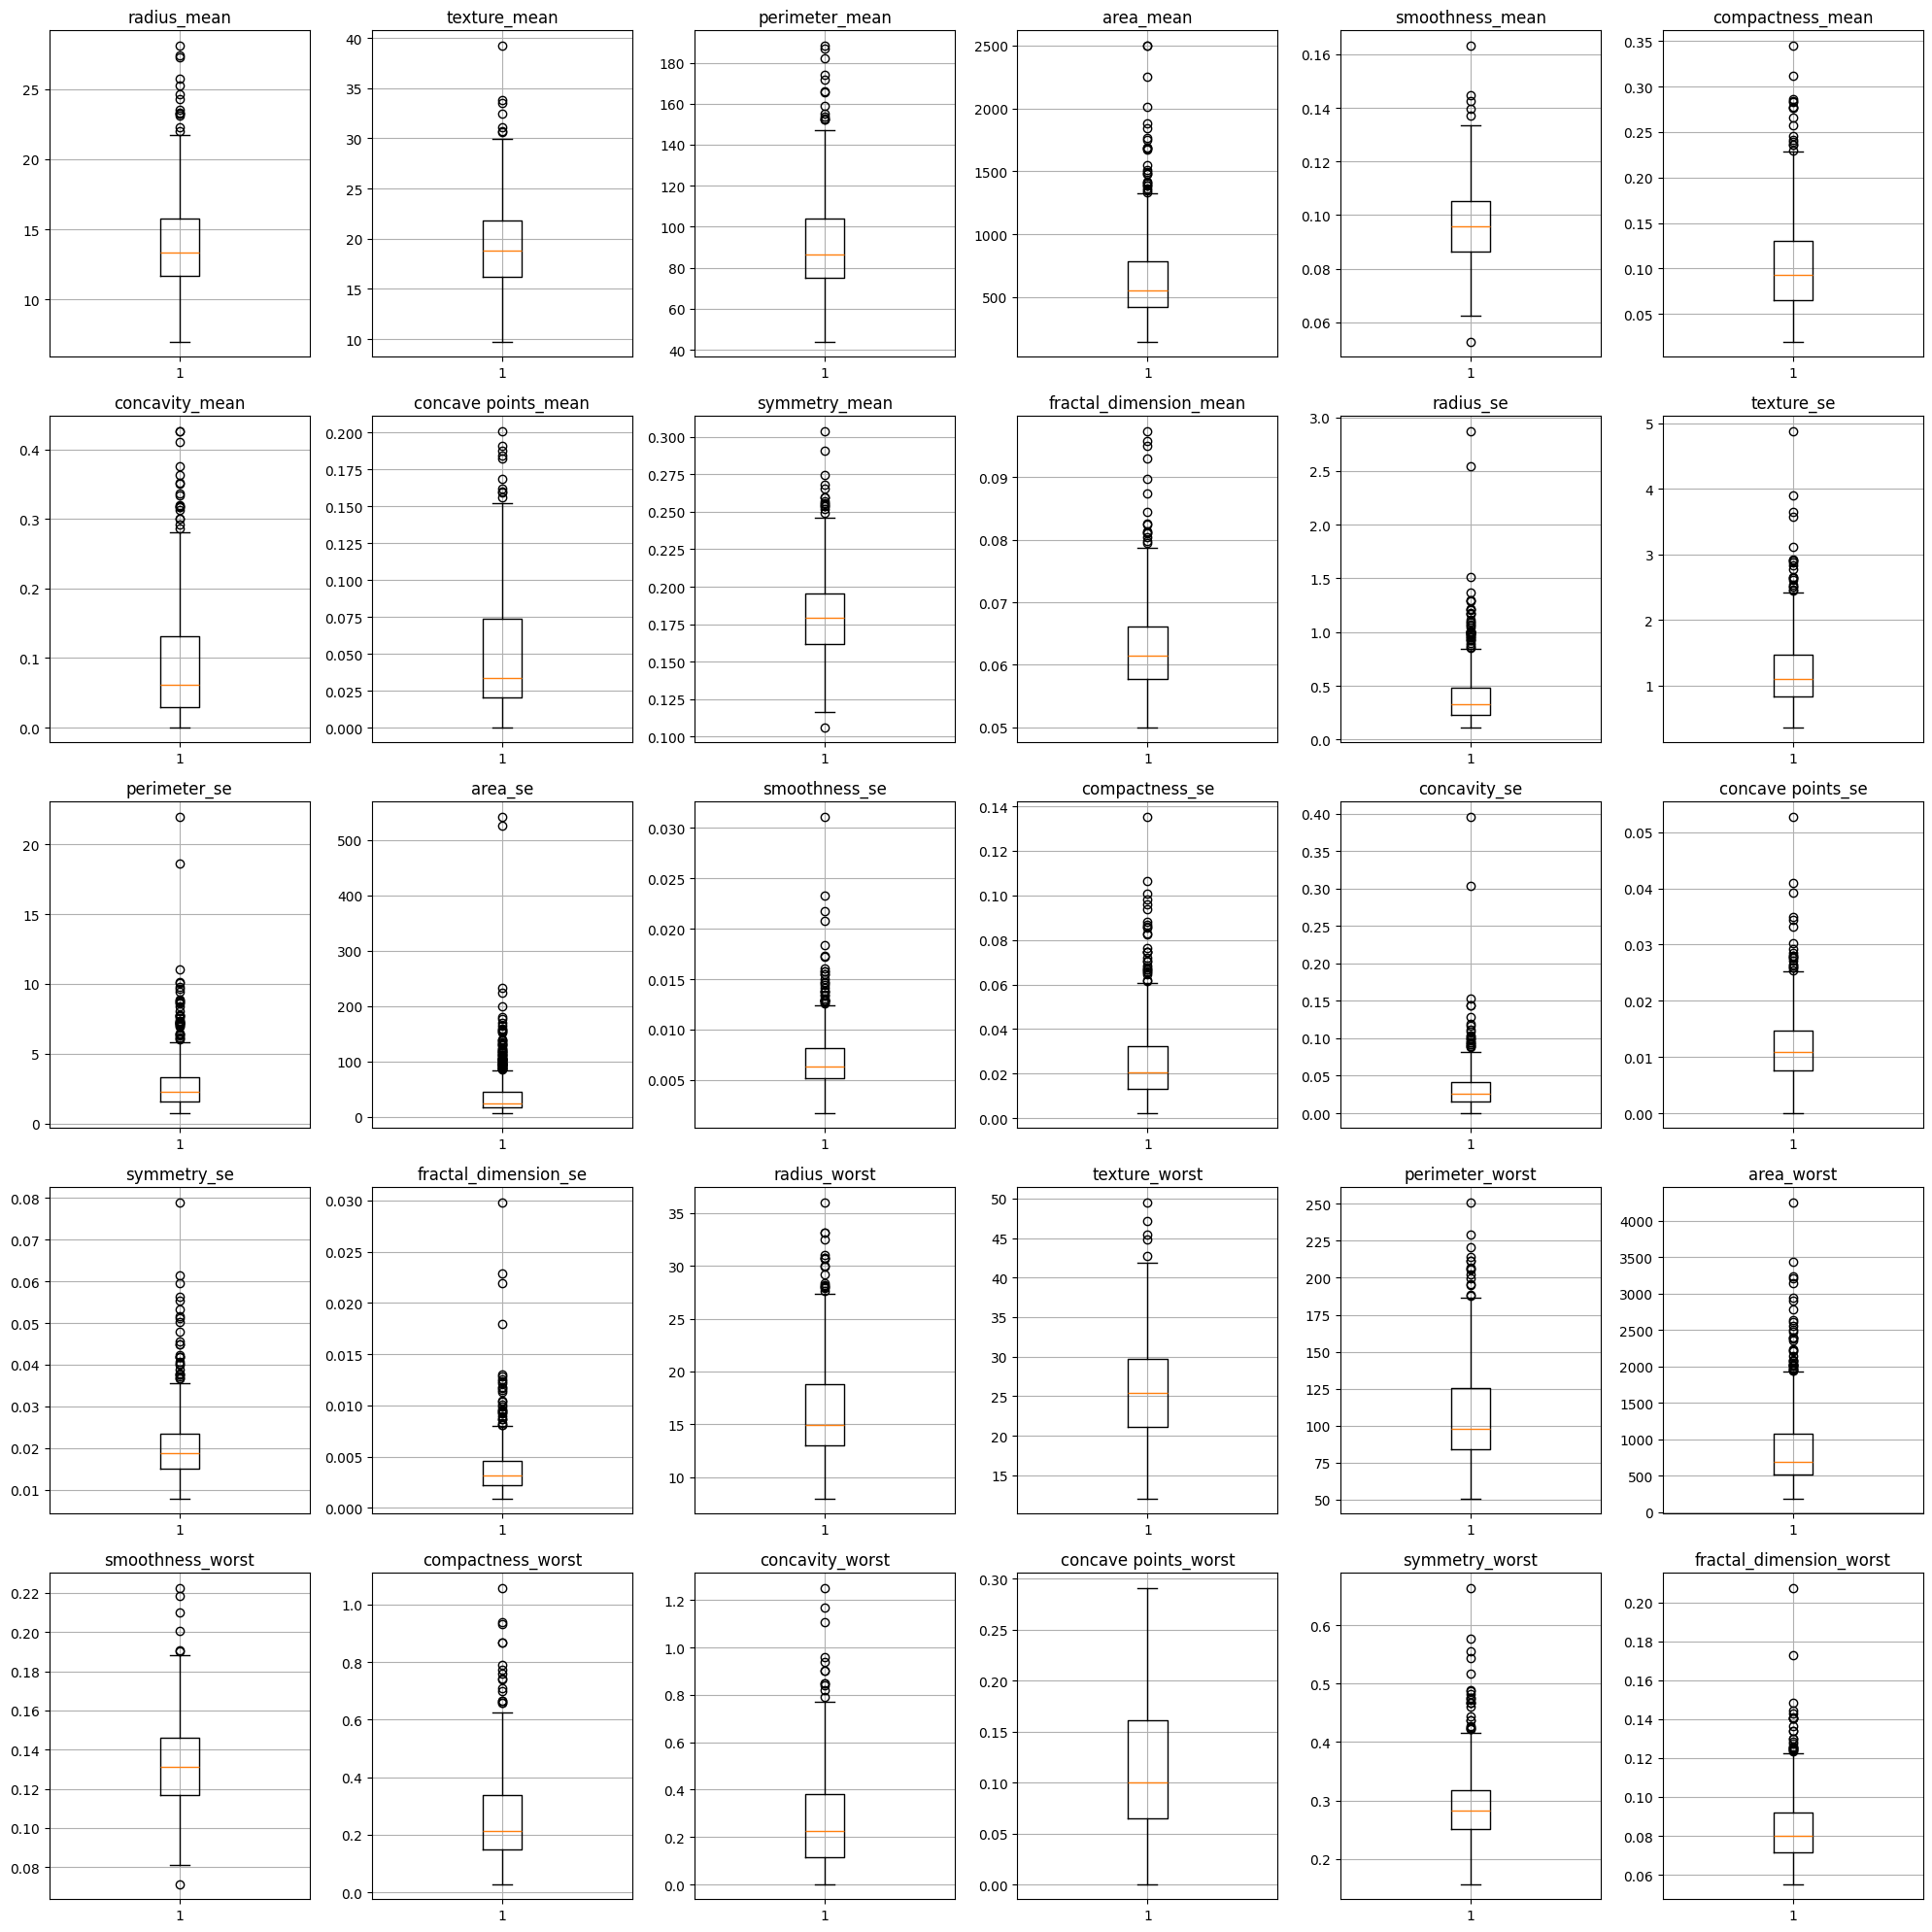

In [12]:
# create box plots for all float variable
# df['concave points_mean'].plot(kind='box')

cols = df.columns[1:]
fig = plt.figure(figsize=(20,20))
ax = fig.subplots(ncols=6, nrows=5)

for i, col in enumerate(cols):
    ax[i//6, i%6].boxplot(df[col])
    ax[i//6, i%6].set_title(col)
    ax[i//6, i%6].grid(True)

plt.tight_layout()
plt.show()
fig.savefig('boxplots.png')



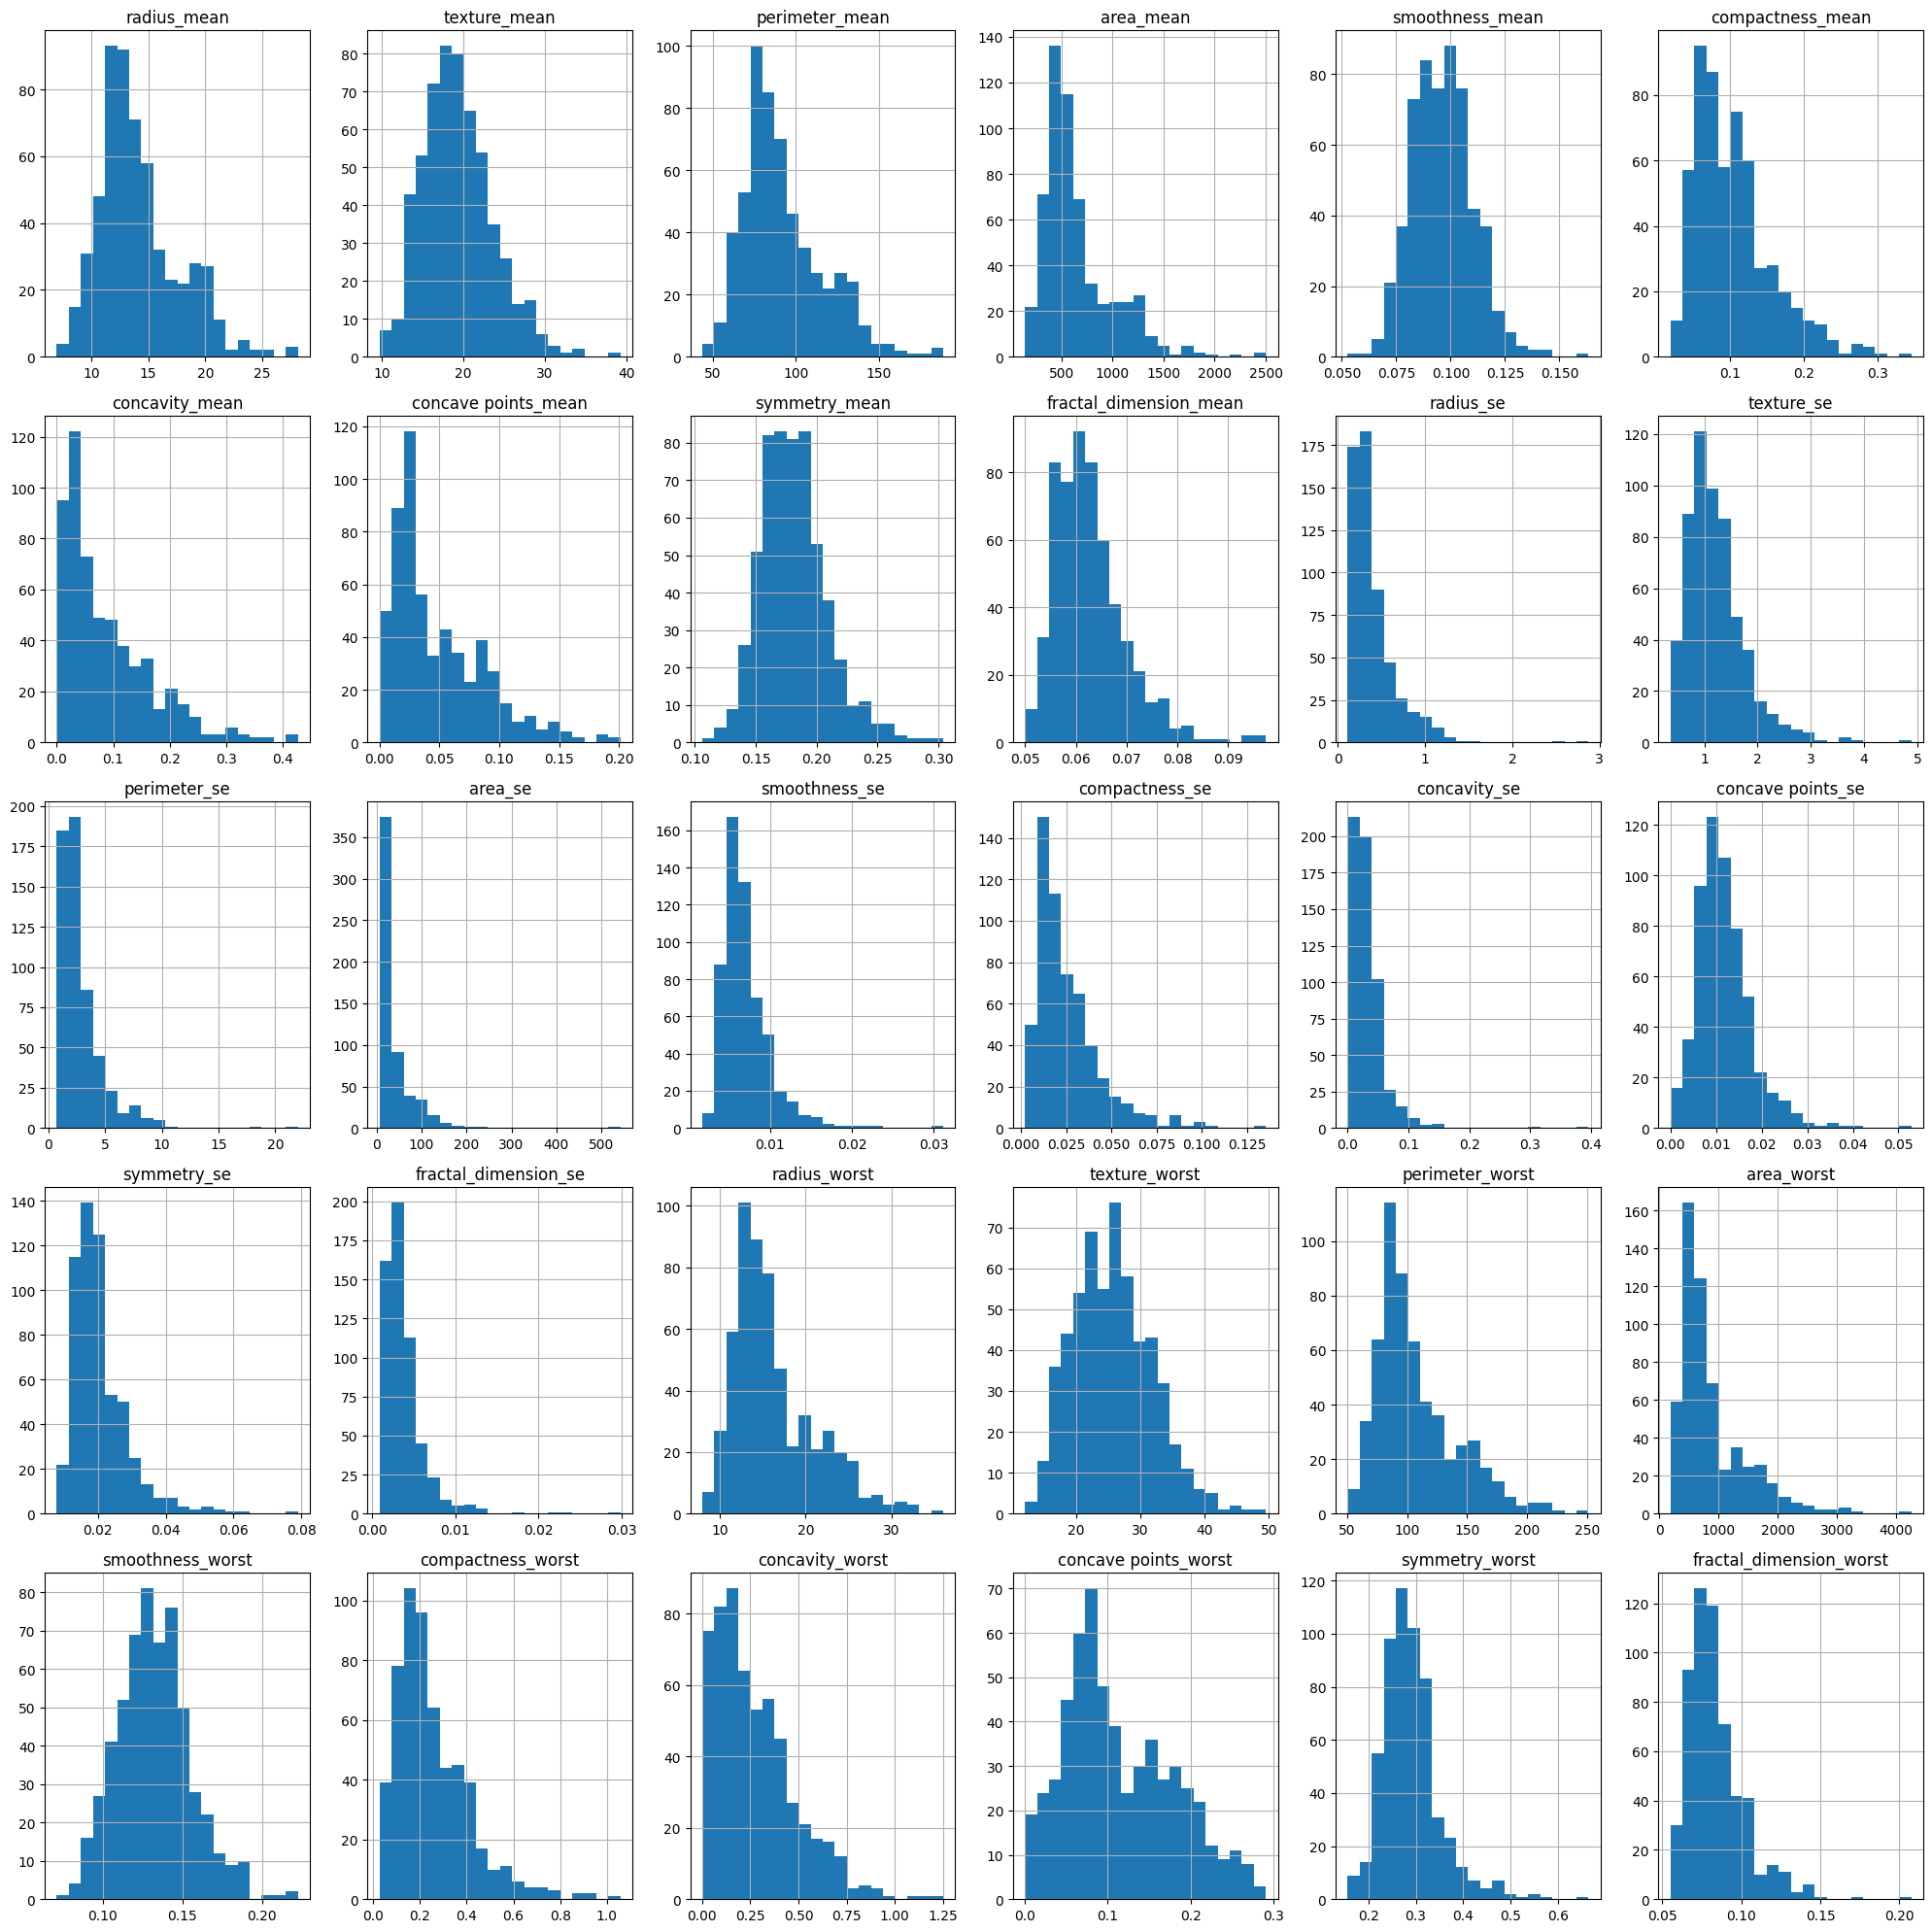

In [13]:
fig = plt.figure(figsize=(20,20))
ax = fig.subplots(ncols=6, nrows=5)

for i, col in enumerate(cols):
    ax[i//6, i%6].hist(df[col], bins=20)
    ax[i//6, i%6].set_title(col)
    ax[i//6, i%6].grid(True)

plt.tight_layout()
plt.show()
fig.savefig('histograms.png')

##Distribution of Diagnosis

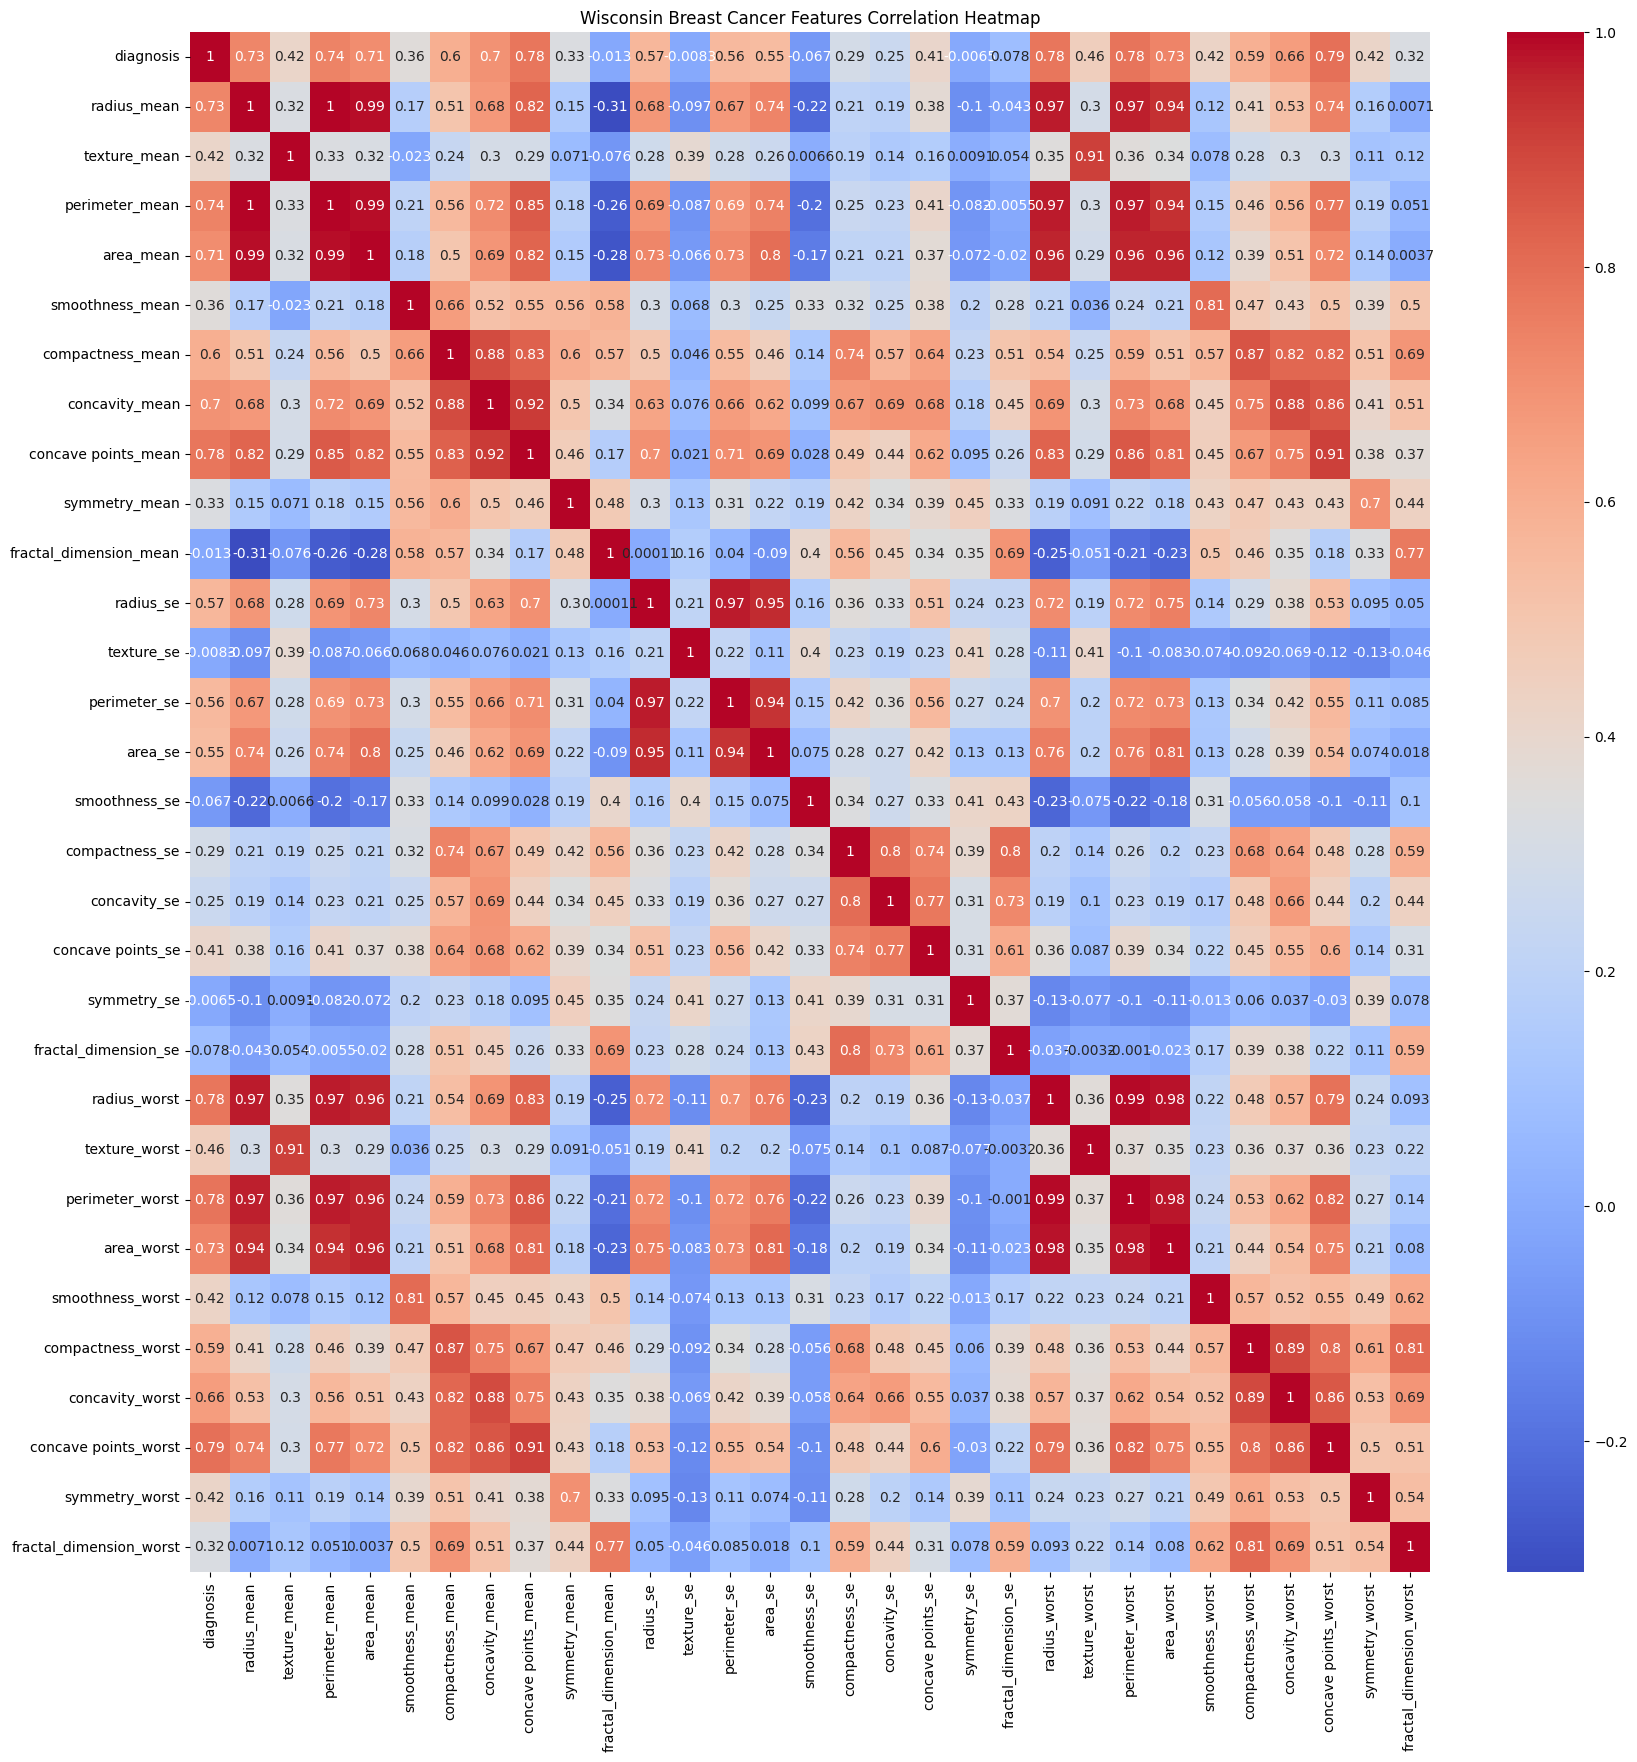

In [14]:
#create a correlation heatmap
plt.figure(figsize=(20,20))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Wisconsin Breast Cancer Features Correlation Heatmap')
plt.savefig('correlation_heatmap.png')
plt.show()

In [15]:
# create scaled features
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']
X_norm = StandardScaler().fit(X).transform(X)



In [16]:
# splitting the dataset
X_train, X_test, y_train, y_test = train_test_split( X_norm, y, test_size=0.2, random_state=4)

In [17]:
# Logistic Regression
LR = LogisticRegression(max_iter=1000, solver='lbfgs')
LR_param_grid = {
    'C': [0.1, 1, 10],
    'penalty': ['l2']
}
# Use GridSearchCV to fine tune hyperparameters
LR_grid = GridSearchCV(LR, LR_param_grid, cv=5, scoring='roc_auc')
LR_grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000),
             param_grid={'C': [0.1, 1, 10], 'penalty': ['l2']},
             scoring='roc_auc')

In [18]:
# Get a score for the model
LR_grid.best_estimator_.score(X_test, y_test)

0.9912280701754386

In [19]:
# The resulting best hyperparameters
LR_grid.best_params_

{'C': 0.1, 'penalty': 'l2'}

In [20]:
# Use the model to predict Y for the testing set
yhat = LR_grid.best_estimator_.predict(X_test)
yhat[:10]

array([0, 0, 1, 1, 0, 0, 0, 0, 1, 0])

In [21]:
# Get a list of the probability an observation is either malignant or benign
# The returned object is a numpy array with a pair of probabilities (the first
# is the probability that the observation is Malignant, and the second is the
# probability that an observation is benign)
yhat_prob = LR_grid.best_estimator_.predict_proba(X_test)
# print first ten observations and format as percentages
print(np.round(yhat_prob[:10], 2))

[[0.62 0.38]
 [0.99 0.01]
 [0.   1.  ]
 [0.02 0.98]
 [0.53 0.47]
 [0.52 0.48]
 [0.99 0.01]
 [1.   0.  ]
 [0.36 0.64]
 [0.79 0.21]]


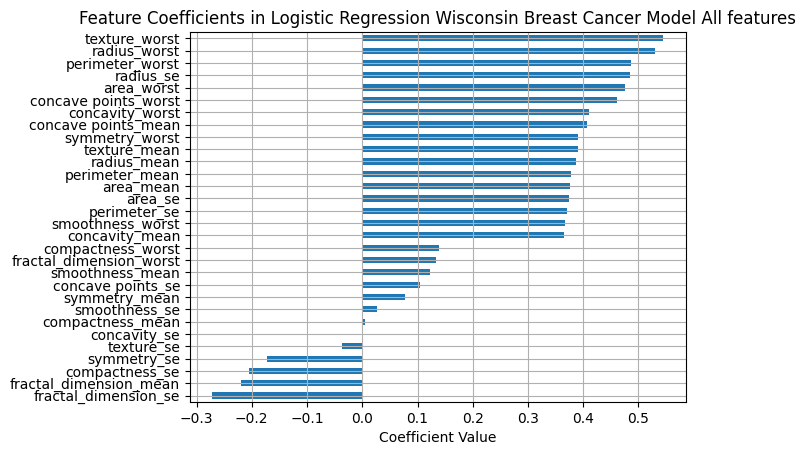

In [22]:
plot_coef(LR_grid.best_estimator_, X, 'feature_coefficients', 'All features')

In [23]:
log_loss(y_test, yhat_prob)

0.09505042559397929

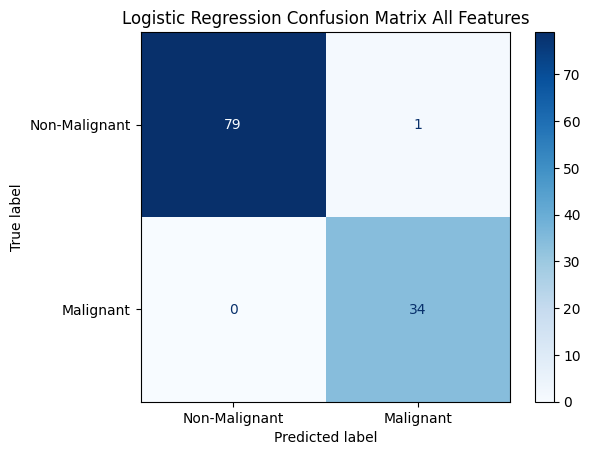

In [24]:
conf_matrix(y_test, yhat, 'confusion_matrix_AllFeatures.png', 'All Features')

In [25]:
y_proba = LR_grid.best_estimator_.predict_proba(X_test)[:, 1]

metrics = compute_metrics(y_test, yhat, y_proba)

for key, value in metrics.items():
    print(f"{key.capitalize()}: {value:.3f}")


Accuracy: 0.991
Precision: 0.971
Recall: 1.000
F1: 0.986
Roc_auc: 0.999
False_negatives: 0.000


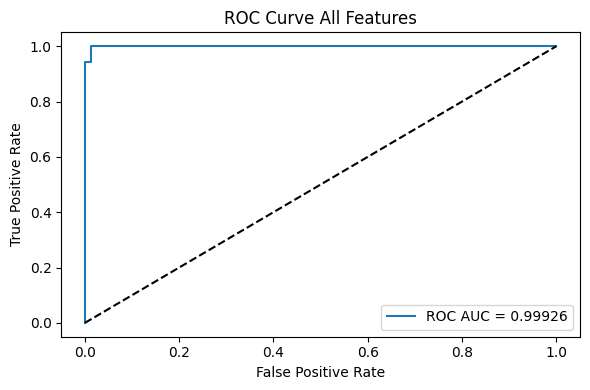

In [26]:
# ROC curve plot
plot_roc_curve(y_test, y_proba, metrics, 'roc_curve_AllFeatures.png', 'All Features')


In [27]:
# # Save model so it can be reused elsewhere
# joblib.dump(LR_grid.best_estimator_, "WBC_logistic_regression_model.pkl")
# print("Model saved successfully!")

## Using a reduced number of high correlation value features:
Now that we have a working model, the idea is to attempt to simplify the model, while retaining the same accuracy scores.

In [28]:
'''
######## Correlation of feature with diagnosis ########
concave points_worst       0.793566
perimeter_worst            0.782914
concave points_mean        0.776614
radius_worst               0.776454
perimeter_mean             0.742636
area_worst                 0.733825
radius_mean                0.730029
area_mean                  0.708984
concavity_mean             0.696360
concavity_worst            0.659610
compactness_mean           0.596534
compactness_worst          0.590998
radius_se                  0.567134
perimeter_se               0.556141
area_se                    0.548236
texture_worst              0.456903
smoothness_worst           0.421465
symmetry_worst             0.416294
texture_mean               0.415185
concave points_se          0.408042
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactness_se             0.292999
concavity_se               0.253730
fractal_dimension_se       0.077972
symmetry_se               -0.006522
texture_se                -0.008303
fractal_dimension_mean    -0.012838
smoothness_se             -0.067016
'''
# Create test variables with a reduced amount of features for testing
top_10_features = ['concave points_worst', 'perimeter_worst', 'concave points_mean', 'radius_worst', 'perimeter_mean',
                   'area_worst', 'radius_mean', 'area_mean', 'concavity_mean', 'concavity_worst']
top_15_features = [top_10_features + ['compactness_mean', 'compactness_worst', 'radius_se', 'perimeter_se', 'area_se']][0]
top_20_features = [top_15_features + ['texture_worst', 'smoothness_worst', 'symmetry_worst', 'texture_mean', 'concave points_se']][0]
non_colinear = ['concave points_worst', 'perimeter_worst', 'radius_worst', 'area_worst', 'compactness_mean',
                'texture_worst', 'smoothness_worst', 'symmetry_worst', 'fractal_dimension_worst']

In [35]:
# create scaled features
X2 = df[top_10_features] # use test variable here
y = df['diagnosis']
X2_norm = StandardScaler().fit(X2).transform(X2)

# splitting the dataset
X2_train, X2_test, y_train, y_test = train_test_split( X2_norm, y, test_size=0.2, random_state=4)

# Logistic Regression with parameters {'C': 0.1, 'penalty': 'l2'}
LR2 = LogisticRegression(max_iter=1000, solver='lbfgs', C=0.1, penalty='l2')
LR2.fit(X2_train, y_train)

#Print regression score comparison against model with all features
print('With all features:', LR_grid.best_estimator_.score(X_test, y_test))
print('With reduced features', LR2.score(X2_test, y_test))

#

With all features: 0.9912280701754386
With reduced features 0.9035087719298246


I tested with top 10, 15, and 20 features and saw models with poor performance.

Then using the feature with the highest correlation by category (for example: concave points_worst, concave points_mean, and concave points_se would all be in the 'concave' category) I had a much better performance.

In [30]:
# Use the model to predict Y for the testing set
yhat2 = LR2.predict(X2_test)

y_proba2 = LR2.predict_proba(X2_test)[:, 1]

metrics = compute_metrics(y_test, yhat2, y_proba2)

for key, value in metrics.items():
    print(f"{key.capitalize()}: {value:.3f}")

Accuracy: 0.982
Precision: 0.971
Recall: 0.971
F1: 0.971
Roc_auc: 0.999
False_negatives: 1.000


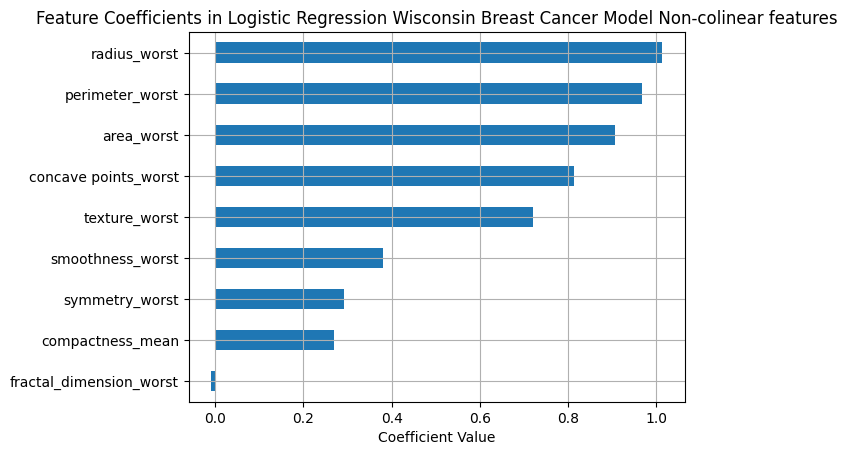

In [31]:

#Plot coeficients
plot_coef(LR2, X2, 'feature_coefficients_Non-colinear', 'Non-colinear features')


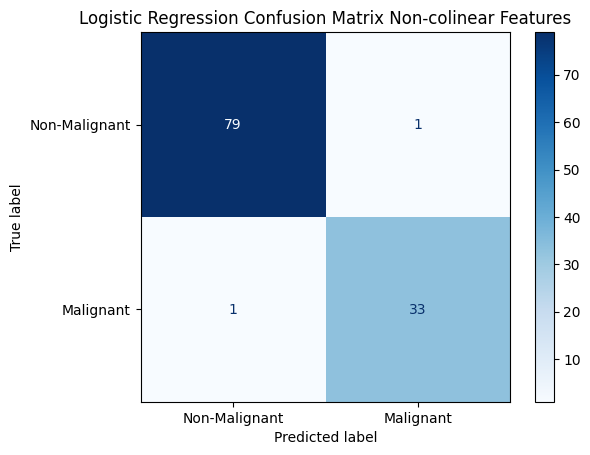

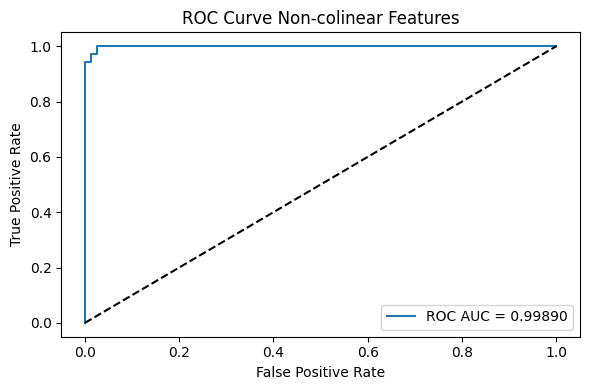

In [32]:
conf_matrix(y_test, yhat2, 'confusion_matrix_Non-colinearFeatures.png', 'Non-colinear Features')
plot_roc_curve(y_test, y_proba2, metrics, 'roc_curve_Non-colinearFeatures.png', 'Non-colinear Features')


Accuracy: 0.982
Precision: 0.944
Recall: 1.000
F1: 0.971
Roc_auc: 0.999
False_negatives: 0.000


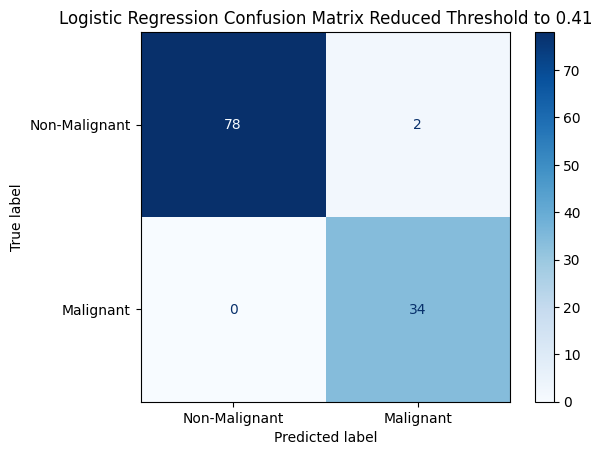

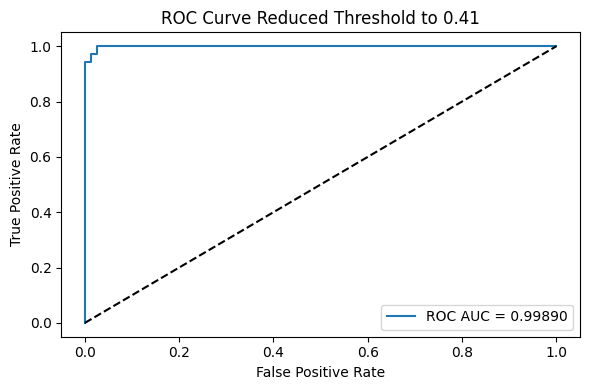

In [33]:
# Use a different threshold for classification that will make sure no false negatives are present
custom_threshold = .41
positive_probabilities = LR2.predict_proba(X2_test)[:, 1]
custom_predictions = (positive_probabilities >= custom_threshold)#.astype(int)
metrics = compute_metrics(y_test, custom_predictions, positive_probabilities)
for key, value in metrics.items():
    print(f"{key.capitalize()}: {value:.3f}")
conf_matrix(y_test, custom_predictions, 'confusion_matrix_ReducedThreshold.png', f'Reduced Threshold to {custom_threshold}')
plot_roc_curve(y_test, positive_probabilities, metrics, 'roc_curve_ReducedThreshold.png', f'Reduced Threshold to {custom_threshold}')



As a different path, test by adding features one by one until there are no false positives.

------------------------------------------------------------
Total features used: 14
['concave points_worst', 'perimeter_worst', 'radius_worst', 'area_worst', 'compactness_mean', 'texture_worst', 'smoothness_worst', 'symmetry_worst', 'fractal_dimension_worst', 'concave points_mean', 'perimeter_mean', 'radius_mean', 'area_mean', 'concavity_mean']
Accuracy: 0.982
Precision: 0.944
Recall: 1.000
F1: 0.971
Roc_auc: 0.999
False_negatives: 0.000


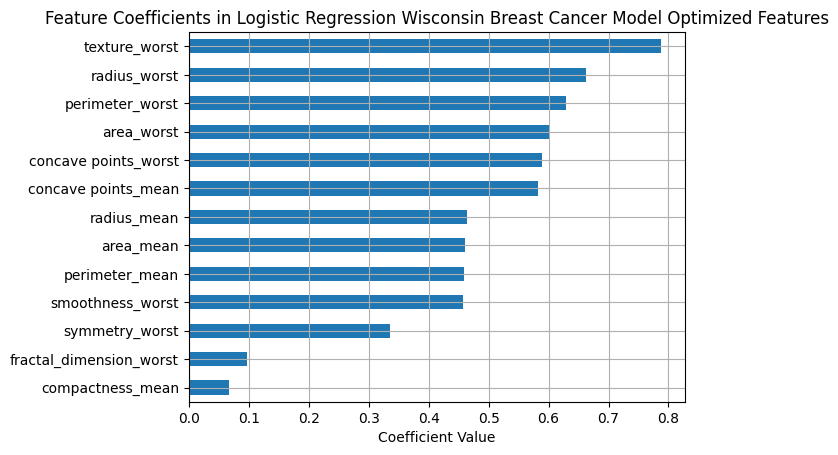

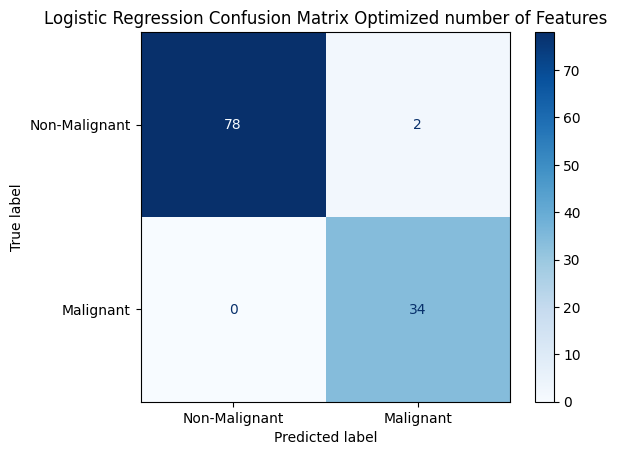

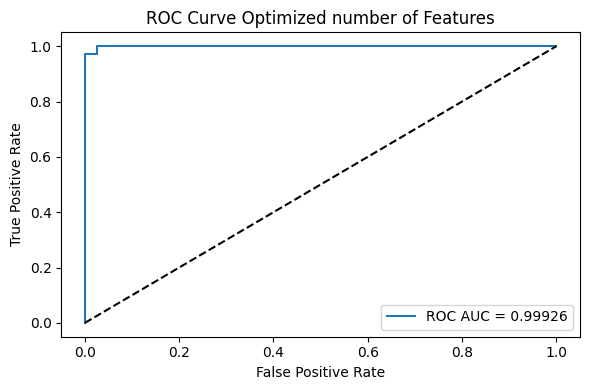

In [34]:
optimized_features = non_colinear
sorted_features = correlation.index.to_list()[1:]
features_to_add = [item for item in sorted_features if item not in non_colinear]

# find the minimum features for a model that will not have any false negatives

LR3 = LogisticRegression(max_iter=1000, solver='lbfgs', C=0.1, penalty='l2')
for i in range(len(features_to_add)):
    # create scaled features
    X3 = df[optimized_features]
    y = df['diagnosis']
    X3_norm = StandardScaler().fit(X3).transform(X3)

    # splitting the dataset
    X3_train, X3_test, y_train, y_test = train_test_split( X3_norm, y, test_size=0.2, random_state=4)

    # Logistic Regression with parameters {'C': 0.1, 'penalty': 'l2'}

    LR3.fit(X3_train, y_train)
    yhat3 = LR3.predict(X3_test)
    y_proba3 = LR3.predict_proba(X3_test)[:, 1]
    metrics = compute_metrics(y_test, yhat3, y_proba3)
    optimized_features.append(features_to_add[i])

    # loop to find the minimun number of features that will
    # yield zero false negatives
    if metrics['false_negatives'] == 0:
      print('-'*60)
      print(f'Total features used: {len(optimized_features)}')
      print(optimized_features)
      for key, value in metrics.items():
        print(f"{key.capitalize()}: {value:.3f}")
      break
plot_coef(LR3, X3, 'feature_coefficients_OptimizedFeatures', 'Optimized Features')
conf_matrix(y_test, yhat3, 'confusion_matrix_OptimizedFeatures.png', 'Optimized number of Features')
plot_roc_curve(y_test, y_proba3, metrics, 'roc_curve_OptimizedFeatures.png', 'Optimized number of Features')

